In [1]:
import torch
import torch.nn as nn
import numpy as np
from pathlib import Path
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from src.data.tabular import split_data
from src.models.VAE import VariationalAutoencoder
from src.models.AE import Autoencoder
from src.hpo.vae_autoencoder_hpo import create_study_vae
from src.hpo.autoencoder_hpo import create_study_ae

h:\Course contents FAU\semester 5\Thesis\final Project\LatentDimAnalysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
digits = load_digits()
X = digits.data
X = StandardScaler().fit_transform(X)  
y = digits.target
X_train, X_val, X_test, y_train, y_val, y_test, encoder = split_data(X, y)
X_train_tensor = torch.from_numpy(X_train).float()
X_val_tensor   = torch.from_numpy(X_val).float()
X_test_tensor  = torch.from_numpy(X_test).float()

y_train_tensor = torch.from_numpy(y_train)
y_val_tensor = torch.from_numpy(y_val)
X_train_val_tensor = torch.cat([X_train_tensor, X_val_tensor], dim=0)
y_train_val_tensor = torch.cat([y_train_tensor, y_val_tensor], dim=0)
X_train_val = X_train_val_tensor.detach().cpu().numpy()
y_train_val = y_train_val_tensor.detach().cpu().numpy()

print("X_train, X_val , X_test split shape",X_train.shape, X_val.shape, X_test.shape)
print("X_train_val split shape", X_train_val.shape)
n_features = X_train.shape[1]

X_train, X_val , X_test split shape (1078, 64) (360, 64) (359, 64)
X_train_val split shape (1438, 64)


In [3]:

study_ae = create_study_ae(
    X_train_tensor,
    X_val_tensor,
    n_epochs=100,
    bottleneck_dim=2,
    n_trials=20,
    study_name="autoencoder_HPO_digits_analysis"
)

print(len(study_ae.trials))
print(study_ae.best_value)
print(study_ae.best_params)

[I 2026-09-12 14:29:04,409] A new study created in memory with name: autoencoder_HPO_digits_analysis
Best trial: 0. Best value: 1.14252:   5%|▌         | 1/20 [00:13<04:14, 13.40s/it]

[I 2026-09-12 14:29:17,816] Trial 0 finished with value: 1.1425247192382812 and parameters: {'lr': 0.0001329291894316216, 'depth': 3, 'activation': 'ReLU', 'n_epochs': 100}. Best is trial 0 with value: 1.1425247192382812.


Best trial: 1. Best value: 0.83855:  10%|█         | 2/20 [00:15<01:57,  6.52s/it]

[I 2026-09-12 14:29:19,515] Trial 1 finished with value: 0.8385499119758606 and parameters: {'lr': 0.003967605077052989, 'depth': 2, 'activation': 'GELU', 'n_epochs': 150}. Best is trial 1 with value: 0.8385499119758606.


Best trial: 1. Best value: 0.83855:  15%|█▌        | 3/20 [00:16<01:13,  4.33s/it]

...

[I 2026-09-12 14:29:29,265] Trial 14 finished with value: 0.8165273070335388 and parameters: {'lr': 0.002969616660570543, 'depth': 2, 'activation': 'GELU', 'n_epochs': 200}. Best is trial 12 with value: 0.7851789593696594.
[I 2026-09-12 14:29:29,300] Trial 15 pruned. 
[I 2026-09-12 14:29:29,330] Trial 16 pruned. 


Best trial: 17. Best value: 0.760584:  90%|█████████ | 18/20 [00:26<00:01,  1.46it/s]

[I 2026-09-12 14:29:31,020] Trial 17 finished with value: 0.7605839967727661 and parameters: {'lr': 0.004344162299150496, 'depth': 2, 'activation': 'GELU', 'n_epochs': 250}. Best is trial 17 with value: 0.7605839967727661.


Best trial: 17. Best value: 0.760584: 100%|██████████| 20/20 [00:26<00:00,  1.34s/it]

[I 2026-09-12 14:29:31,247] Trial 18 pruned. 
[I 2026-09-12 14:29:31,278] Trial 19 pruned. 
20
0.7605839967727661
{'lr': 0.004344162299150496, 'depth': 2, 'activation': 'GELU', 'n_epochs': 250}


In [4]:

study_vae = create_study_vae(
    X_train_tensor,
    X_val_tensor,
    n_epochs=100,
    bottleneck_dim=32,
    n_trials=20,
    study_name="vae_hpo_study"
)

print(len(study_vae.trials))
print(study_vae.best_value)
print(study_vae.best_params)

[I 2026-09-12 14:29:31,317] A new study created in memory with name: vae_hpo_study
Best trial: 0. Best value: 0.913965:   5%|▌         | 1/20 [00:04<01:32,  4.87s/it]

[I 2026-09-12 14:29:36,189] Trial 0 finished with value: 0.9139652848243713 and parameters: {'lr': 0.0001329291894316216, 'depth': 3, 'activation': 'ReLU', 'beta': 0.12389490049257872, 'n_epochs': 450}. Best is trial 0 with value: 0.9139652848243713.


Best trial: 0. Best value: 0.913965:  10%|█         | 2/20 [00:10<01:36,  5.36s/it]

[I 2026-09-12 14:29:41,883] Trial 1 finished with value: 0.9161348342895508 and parameters: {'lr': 0.0006358358856676254, 'depth': 3, 'activation': 'LeakyReLU', 'beta': 0.19556651891602772, 'n_epochs': 150}. Best is trial 0 with value: 0.9139652848243713.


Best trial: 0. Best value: 0.913965:  15%|█▌        | 3/20 [00:12<01:06,  3.90s/it]

...

[I 2026-09-12 14:29:59,057] Trial 14 pruned. 
[I 2026-09-12 14:29:59,085] Trial 15 pruned. 
[I 2026-09-12 14:29:59,113] Trial 16 pruned. 


Best trial: 12. Best value: 0.528223:  90%|█████████ | 18/20 [00:32<00:03,  1.58s/it]

[I 2026-09-12 14:30:03,948] Trial 17 pruned. 
[I 2026-09-12 14:30:03,987] Trial 18 pruned. 


Best trial: 12. Best value: 0.528223: 100%|██████████| 20/20 [00:38<00:00,  1.95s/it]

[I 2026-09-12 14:30:10,268] Trial 19 finished with value: 0.5430793166160583 and parameters: {'lr': 0.003733992059160513, 'depth': 3, 'activation': 'LeakyReLU', 'beta': 0.22658686103653294, 'n_epochs': 350}. Best is trial 12 with value: 0.5282230377197266.
20
0.5282230377197266
{'lr': 0.0031047091819970986, 'depth': 3, 'activation': 'LeakyReLU', 'beta': 0.11135148354975193, 'n_epochs': 400}


In [5]:
from src.hpo.hidden_dims import build_hidden_dims_geo
from src.metrics.knn import compute_knn_score, find_best_neighbors
from src.training.train import train_final_model
from src.training.train_vae import train_final_model_vae


best_params_ae = study_ae.best_params
best_params_vae = study_vae.best_params
activation_functions = {
    "ReLU": nn.ReLU,
    "LeakyReLU": nn.LeakyReLU,
    "GELU": nn.GELU,
    "Tanh": nn.Tanh,
}

input_dim = X_train_val_tensor.shape[1]
bottleneck_range = [1,2,4,8,16,24,30,38,45,50,54,62]

epochs = 400

pca_errors= []
ae_errors = []
vae_errors = []

ae_knn = []
pca_knn = []
vae_knn = []

ae_total_loss = []
ae_recon_loss = []
ae_kl_loss =[]

vae_total_loss = []
vae_recon_loss = []
vae_kl_loss =[]


best_neighbors, best_val_score = find_best_neighbors(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

print("Best neighbors:", best_neighbors)
print("Validation accuracy:", best_val_score)


for k in bottleneck_range:
    torch.manual_seed(42)
    np.random.seed(42)

    final_hidden_dims_ae = build_hidden_dims_geo(
        input_dim,
        latent_dim=k,
        depth = best_params_ae["depth"]
    )

    final_hidden_dims_vae = build_hidden_dims_geo(
            input_dim,
            latent_dim=k,
            depth=best_params_vae["depth"]
    )

    # --------------PCA-----------------
    pca = PCA(n_components=k)
    X_train_reduced_pca = pca.fit_transform(X_train_val)
    X_train_recon_pca = pca.inverse_transform(X_train_reduced_pca)

    X_test_reduced_pca = pca.transform(X_test)

    pca_knn_accuracy = compute_knn_score(
        X_train = X_train_reduced_pca,
        y_train = y_train_val,
        X_test = X_test_reduced_pca,
        y_test = y_test,
        n_neighbors=best_neighbors
    )

    pca_errors.append(np.mean((X_train_val - X_train_recon_pca) ** 2))
    pca_knn.append(pca_knn_accuracy)

    # --------------AE-----------------
    final_ae = Autoencoder(
        n_features=input_dim,
        bottleneck_dim=k,
        hidden_dims_list=final_hidden_dims_ae,
        non_linear=True,
        non_linear_function=activation_functions[
            best_params_ae["activation"]
        ]
    )

    train_loss_ae, test_loss_ae, z_train_val_ae, z_test_ae  = train_final_model(
            final_model=final_ae,
            X_train_val_tensor=X_train_val_tensor,
            X_test_tensor=X_test_tensor, 
            best_params=best_params_ae, 
            epochs=400
        )

    z_train_val_ae = z_train_val_ae.cpu().numpy()
    z_test_ae = z_test_ae.cpu().numpy()

    ae_knn_accuracy = compute_knn_score(
            X_train=z_train_val_ae,
            y_train=y_train_val,
            X_test=z_test_ae,
            y_test=y_test,
            n_neighbors=best_neighbors
    )

    ae_knn.append(ae_knn_accuracy)
    ae_recon_loss.append(train_loss_ae)


    # --------------VAE-----------------
    final_vae = VariationalAutoencoder(
            n_features=input_dim,
            bottleneck_dim=k,
            hidden_dims_list=final_hidden_dims_vae,
            non_linear_function=activation_functions[best_params_vae["activation"]]
    )

    train_loss_vae, test_loss_vae, recon_loss_vae, kl_loss_vae, mu_train_val_vae, mu_test_vae = train_final_model_vae(
            final_model=final_vae,
            X_train_val_tensor=X_train_val_tensor,
            X_test_tensor=X_test_tensor,
            best_params=best_params_vae,
            epochs=400
    )

    mu_train_val_vae = mu_train_val_vae.cpu().numpy()
    mu_test_vae = mu_test_vae.cpu().numpy()

    vae_knn_accuracy = compute_knn_score(
            X_train=mu_train_val_vae,
            y_train=y_train_val,
            X_test=mu_test_vae,
            y_test=y_test,
            n_neighbors=best_neighbors
    )

    vae_knn.append(vae_knn_accuracy)
    vae_total_loss.append(train_loss_vae)
    vae_recon_loss.append(recon_loss_vae)
    vae_kl_loss.append(kl_loss_vae)
    
    print(
        f"k={k:>3} "
        f"AE KNN={ae_knn_accuracy:.4f} "
        f"AE Loss={train_loss_ae:.4f} "
        f"Test Loss AE ={test_loss_ae:.4f} "
        f"VAE KNN={vae_knn_accuracy:.4f} "
        f"VAE Loss={train_loss_vae:.4f} "
        f"Test Loss VAE={test_loss_vae:.4f} "
    )


    

Best neighbors: 5
Validation accuracy: 0.9583333333333334
k=  1 AE KNN=0.4930 AE Loss=0.6462 Test Loss AE =0.7051 VAE KNN=0.1838 VAE Loss=0.9055 Test Loss VAE=0.8485 
k=  2 AE KNN=0.7187 AE Loss=0.4612 Test Loss AE =0.5791 VAE KNN=0.3454 VAE Loss=0.8004 Test Loss VAE=0.7861 
k=  4 AE KNN=0.8273 AE Loss=0.3136 Test Loss AE =0.3741 VAE KNN=0.5989 VAE Loss=0.5964 Test Loss VAE=0.5971 
k=  8 AE KNN=0.9136 AE Loss=0.2021 Test Loss AE =0.2473 VAE KNN=0.4986 VAE Loss=0.4774 Test Loss VAE=0.5148 
k= 16 AE KNN=0.9331 AE Loss=0.1442 Test Loss AE =0.1807 VAE KNN=0.5794 VAE Loss=0.3538 Test Loss VAE=0.4083 
k= 24 AE KNN=0.9415 AE Loss=0.1107 Test Loss AE =0.1459 VAE KNN=0.5738 VAE Loss=0.3098 Test Loss VAE=0.3572 
k= 30 AE KNN=0.9471 AE Loss=0.0953 Test Loss AE =0.1322 VAE KNN=0.5738 VAE Loss=0.2866 Test Loss VAE=0.3457 
k= 38 AE KNN=0.9582 AE Loss=0.0890 Test Loss AE =0.1264 VAE KNN=0.6323 VAE Loss=0.2501 Test Loss VAE=0.3030 
k= 45 AE KNN=0.9582 AE Loss=0.0754 Test Loss AE =0.1102 VAE KNN=0.5655

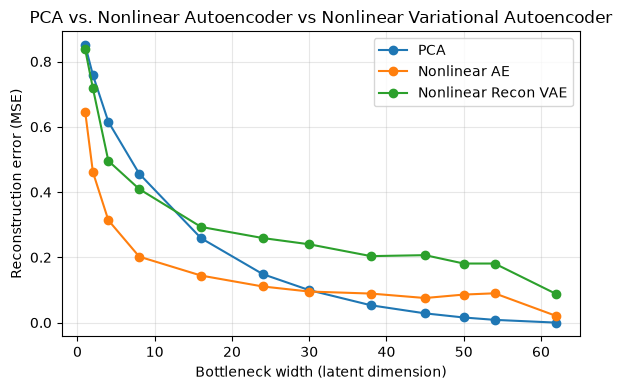

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(bottleneck_range, pca_errors, marker="o", label="PCA")
plt.plot(bottleneck_range, ae_recon_loss, marker="o", label="Nonlinear AE")
plt.plot(bottleneck_range, vae_recon_loss, marker="o", label="Nonlinear Recon VAE")
plt.xlabel("Bottleneck width (latent dimension)")
plt.ylabel("Reconstruction error (MSE)")
plt.title("PCA vs. Nonlinear Autoencoder vs Nonlinear Variational Autoencoder")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

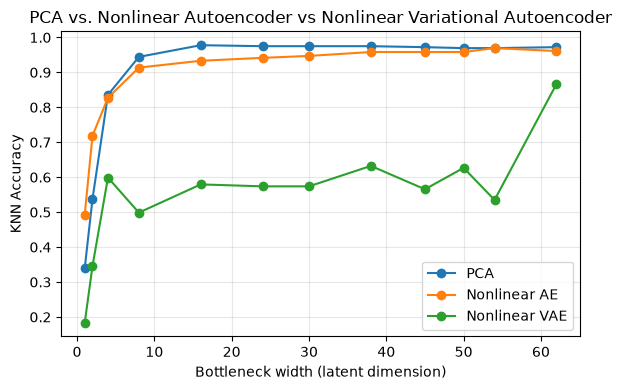

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(bottleneck_range, pca_knn, marker="o", label="PCA")
plt.plot(bottleneck_range, ae_knn, marker="o", label="Nonlinear AE")
plt.plot(bottleneck_range, vae_knn, marker="o", label="Nonlinear VAE")
plt.xlabel("Bottleneck width (latent dimension)")
plt.ylabel("KNN Accuracy")
plt.title("PCA vs. Nonlinear Autoencoder vs Nonlinear Variational Autoencoder")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()